# Freistoß ohne Luftwiderstand

Ball kommt über die Mauer.
TOR!!!
31.2313663412842 -0.006641760415369225
1.723


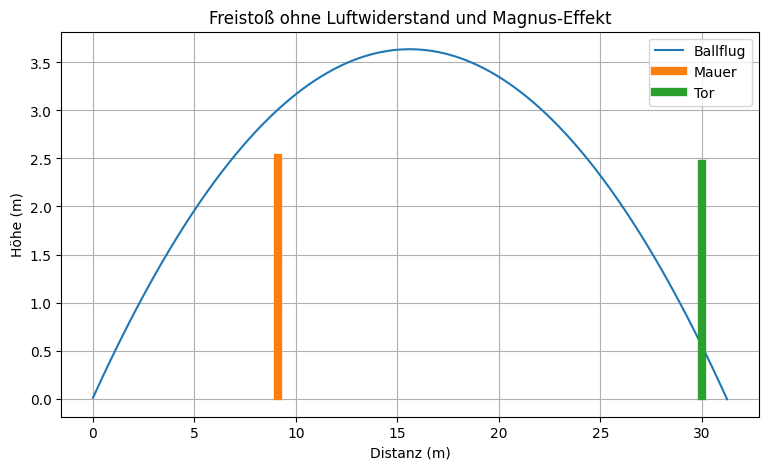

3.6370837571748886
x-Postion bei maximaler Höhe:  15.606620092770997
hölfte der Flugbahn:  15.62474624851173


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------

g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 0   # Dichte der Luft in kg/m^3
lwBeiwert = 0.2   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.2    # Auftriebsbeiwert (nicht perfekt glatt)
r = 0.11    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.43    # Masse des Balls in kg

# ----------------------------------------------------------------------
# Freistoß werte variabel zum eintellen
# ---------------------------------------------------------------------

v0 = 20     # Anfangsgeschwindigkeit in m/s
winkel = 25 # Abschusswinkel in Grad
spin = -10   # Positiver Wert = Backspin, Negativer Wert = Topspin

# -----------------------------
# Spielfeld in m
# -----------------------------

mauer_x = 9.15
mauer_h = 2.50

tor_x = 30.0
tor_h = 2.44

#---------------------------------
# Berechnung von 
#---------------------------------

winkel_rad = np.radians(winkel)             # Umrechnung des Winkels von Grad in Bogenmaß weil trigonometrische Funktionen in Python Bogenmaß erwarten
v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([0.0, 0.0])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_mauer = False
im_tor = False



# -----------------------------
# Simulation
# -----------------------------

dt= 0.001  # Zeitschritt in Sekunden
t = 0.0     # Startzeit
while pos[1] >= 0: # and pos[0] <= tor_x + 1:       Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    t = round(t + dt, 3)  # Zeit aktualisieren und auf 3 Dezimalstellen runden
    v_ges = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_lw = -0.5 * dichteLuft * lwBeiwert * A * v_ges * v    # Luftwiderstand
    
    F_magnus = 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_g = np.array([0, -m*g])             # Schwerkraft
    a = (F_lw + F_magnus +    F_g) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - mauer_x) < 0.05 and pos[1] > mauer_h:
        ueber_mauer = True
    
    # Prüfen: im Tor?
    if abs(pos[0] - tor_x) < 0.05 and 0 < pos[1] < tor_h:
        im_tor = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_mauer:
    print("Ball kommt über die Mauer.")
else:
    print("Ball bleibt in der Mauer hängen.")

if im_tor and ueber_mauer:
    print("TOR!!!")
else:
    print("Kein Tor.")

print(pos[0], pos[1])
print(t)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([mauer_x, mauer_x], [0.03, mauer_h], linewidth=6, label="Mauer")

# Tor
plt.plot([tor_x, tor_x], [0.03, tor_h], linewidth=6, label="Tor")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Freistoß ohne Luftwiderstand und Magnus-Effekt")
plt.legend()
plt.grid()
plt.show()

print (np.max(positionen[:,1]))
print ("x-Postion bei maximaler Höhe: ", positionen[np.argmax(positionen[:,1]), 0])
print("hölfte der Flugbahn: ", positionen[len(positionen)//2, 0])

Ball kommt über die Mauer.
Kein Tor.
25.506175111533494 -0.0008136064706663285


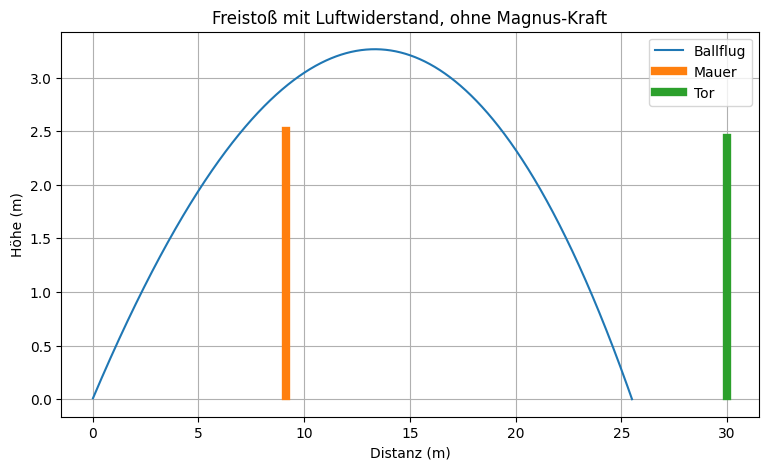

3.264442660959661
x-Postion bei maximaler Höhe:  13.338330850465866
hölfte der Flugbahn:  13.665363075661832


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------

g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 1.225   # Dichte der Luft in kg/m^3
lwBeiwert = 0.2   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.2    # Auftriebsbeiwert (nicht perfekt glatt)
r = 0.11    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.43    # Masse des Balls in kg

# ----------------------------------------------------------------------
# Freistoß werte variabel zum eintellen
# ---------------------------------------------------------------------

v0 = 20     # Anfangsgeschwindigkeit in m/s
winkel = 25 # Abschusswinkel in Grad
spin = 7   # Positiver Wert = Backspin, Negativer Wert = Topspin

# -----------------------------
# Spielfeld in m
# -----------------------------

mauer_x = 9.15
mauer_h = 2.50

tor_x = 30.0
tor_h = 2.44

#---------------------------------
# Berechnung von 
#---------------------------------

winkel_rad = np.radians(winkel)             # Umrechnung des Winkels von Grad in Bogenmaß weil trigonometrische Funktionen in Python Bogenmaß erwarten
v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([0.0, 0.0])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_mauer = False
im_tor = False

# -----------------------------
# Simulation
# -----------------------------

dt = 0.001
while pos[1] >= 0: # and pos[0] <= tor_x + 1:       Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    v_ges = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_lw = -0.5 * dichteLuft * lwBeiwert * A * v_ges * v    # Luftwiderstand
    
    F_magnus = 0 # 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]])  // Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_g = np.array([0, -m*g])             # Schwerkraft
    a = (F_lw + F_magnus +    F_g) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - mauer_x) < 0.05 and pos[1] > mauer_h:
        ueber_mauer = True
    
    # Prüfen: im Tor?
    if abs(pos[0] - tor_x) < 0.05 and 0 < pos[1] < tor_h:
        im_tor = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_mauer:
    print("Ball kommt über die Mauer.")
else:
    print("Ball bleibt in der Mauer hängen.")

if im_tor and ueber_mauer:
    print("TOR!!!")
else:
    print("Kein Tor.")

print(pos[0], pos[1])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([mauer_x, mauer_x], [0.03, mauer_h], linewidth=6, label="Mauer")

# Tor
plt.plot([tor_x, tor_x], [0.03, tor_h], linewidth=6, label="Tor")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Freistoß mit Luftwiderstand, ohne Magnus-Kraft")
plt.legend()
plt.grid()
plt.show()
print (np.max(positionen[:,1]))
print ("x-Postion bei maximaler Höhe: ", positionen[np.argmax(positionen[:,1]), 0])
print("hölfte der Flugbahn: ", positionen[len(positionen)//2, 0])

# Freistoß mit Luftwiderstand und Magnus-Kraft

Ball kommt über die Mauer.
TOR!!!
33.10324719610303 -0.003313291591557216


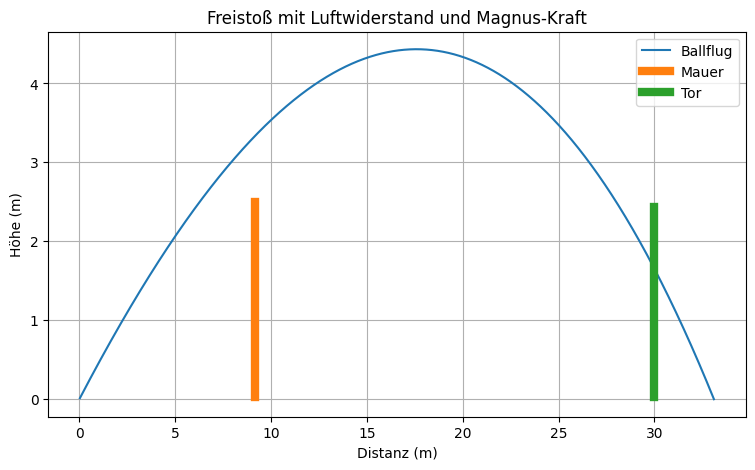

4.434006288413636
x-Postion bei maximaler Höhe:  17.590866284920896
hölfte der Flugbahn:  18.02533836952041


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------

g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 1.2   # Dichte der Luft in kg/m^3
lwBeiwert = 0.2   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.2    # Auftriebsbeiwert (nicht perfekt glatt)
r = 0.11    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.43    # Masse des Balls in kg

# ----------------------------------------------------------------------
# Freistoß werte variabel zum eintellen
# ---------------------------------------------------------------------

v0 = 22  # Anfangsgeschwindigkeit in m/s
winkel = 25 # Abschusswinkel in Grad
spin = 7   # Positiver Wert = Backspin, Negativer Wert = Topspin

# -----------------------------
# Spielfeld in m
# -----------------------------

mauer_x = 9.15
mauer_h = 2.50

tor_x = 30.0
tor_h = 2.44

#---------------------------------
# Berechnung von 
#---------------------------------

winkel_rad = np.radians(winkel)             # Umrechnung des Winkels von Grad in Bogenmaß weil trigonometrische Funktionen in Python Bogenmaß erwarten
v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([0.0, 0.0])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_mauer = False
im_tor = False



# -----------------------------
# Simulation
# -----------------------------

dt = 0.001  # Zeitschritt in Sekunden

while pos[1] >= 0: # and pos[0] <= tor_x + 1:       Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    v_ges = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_lw =  -0.5 * dichteLuft * lwBeiwert * A * v_ges * v    # Luftwiderstand
    
    F_magnus =  0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_g = np.array([0, -m*g])             # Schwerkraft
    a = (F_lw + F_magnus +    F_g) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - mauer_x) < 0.05 and pos[1] > mauer_h:
        ueber_mauer = True
    
    # Prüfen: im Tor?
    if abs(pos[0] - tor_x) < 0.05 and 0 < pos[1] < tor_h:
        im_tor = True
    

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_mauer:
    print("Ball kommt über die Mauer.")
else:
    print("Ball bleibt in der Mauer hängen.")

if im_tor and ueber_mauer:
    print("TOR!!!")
else:
    print("Kein Tor.")

print(pos[0], pos[1])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([mauer_x, mauer_x], [0.03, mauer_h], linewidth=6, label="Mauer")

# Tor
plt.plot([tor_x, tor_x], [0.03, tor_h], linewidth=6, label="Tor")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Freistoß mit Luftwiderstand und Magnus-Kraft")
plt.legend()
plt.grid()
plt.show()

#------------------------------
# Auswertung der Flugbahn
#------------------------------
print (np.max(positionen[:,1]))
print ("x-Postion bei maximaler Höhe: ", positionen[np.argmax(positionen[:,1]), 0])
print("hölfte der Flugbahn: ", positionen[len(positionen)//2, 0])

Ball kommt über das Netz.
Kein Punkt.
23.895999999999706 -0.0033609299999871342


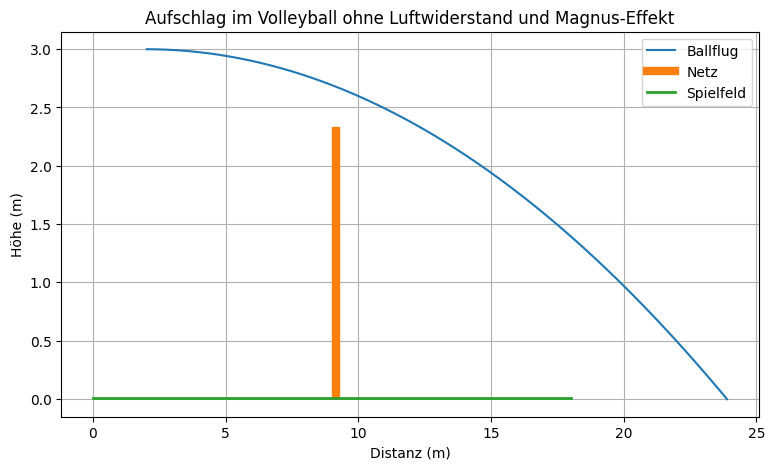

False


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
#  werte variabel zum eintellen
# ---------------------------------------------------------------------
v0 = 28     # Anfangsgeschwindigkeit in m/s
winkel = 0
spin = -9   # positiver Wert = Backspin, negativer Wert = Topspin genuzter Wer =-9
aufschlagHöhe = 3.0
dt = 0.001

# -----------------------------
# Konstanten
# -----------------------------
g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 0   # Dichte der Luft in kg/m^3
lwBeiwert = 0.17   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.3    # Magnus-Koeffizient (nicht perfekt glatt)
r = 0.105    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.270    # Masse des Balls in kg

# -----------------------------
# Spielfeld
# -----------------------------
netz_x = 9.15
netz_h = 2.30

FeldEnde = 18.0

# ----------------------------
# Simulation
# -----------------------------
winkel_rad = np.radians(winkel)

v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([2.0, aufschlagHöhe])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_netz = False
im_feld = False

while pos[1] >= 0:      # Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    gesamtgeschwindigkeit = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_drag = -0.5 * dichteLuft * lwBeiwert * A * gesamtgeschwindigkeit * v    # Luftwiderstand
    
    F_magnus = 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_gravity = np.array([0, -m*g])             # Schwerkraft
    a = (F_drag + F_magnus + F_gravity) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - netz_x) < 0.03 and pos[1] > netz_h:
        ueber_netz = True
    
    # Prüfen: im Tor?
    if pos[0] <= FeldEnde and pos[1] <= 0:
        im_feld = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_netz:
    print("Ball kommt über das Netz.")
else:
    print("Ball bleibt im Netz hängen.")

if im_feld and ueber_netz:
    print("Punkt!!!")
else:
    print("Kein Punkt.")

print(pos[0], pos[1])
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([netz_x, netz_x], [0.03, netz_h], linewidth=6, label="Netz")

# Feld
plt.plot([18, 0.0], [0.01, 0.01], linewidth=2, label="Spielfeld")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Aufschlag im Volleyball ohne Luftwiderstand und Magnus-Effekt")
plt.legend()
plt.grid()
plt.show()
print(im_feld)

# Aufschlag mit Luftwiderstand, ohne Magnus-Kraft

Ball kommt über das Netz.
Kein Punkt.
21.968133157861992 -0.00019740821582039329


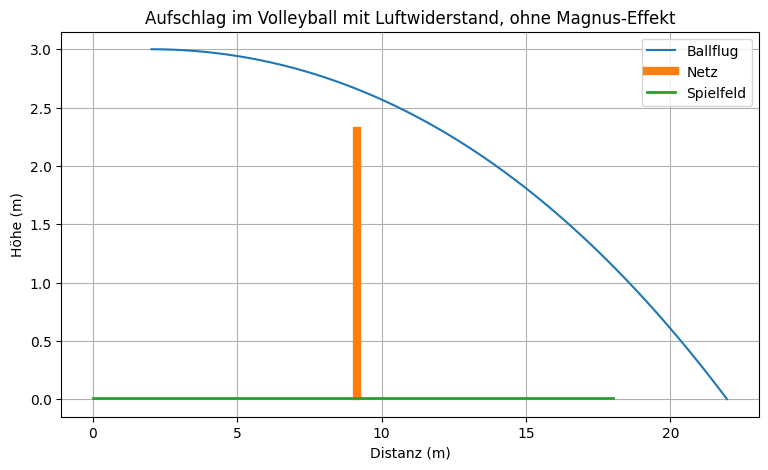

False


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
#  werte variabel zum eintellen
# ---------------------------------------------------------------------
v0 = 28     # Anfangsgeschwindigkeit in m/s
winkel = 0
spin = -9   # positiver Wert = Backspin, negativer Wert = Topspin genuzter Wer =-9
aufschlagHöhe = 3.0
dt = 0.001

# -----------------------------
# Konstanten
# -----------------------------
g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 1.2 # Dichte der Luft in kg/m^3
lwBeiwert = 0.17   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.3    # Magnus-Koeffizient (nicht perfekt glatt)
r = 0.105    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.270    # Masse des Balls in kg

# -----------------------------
# Spielfeld
# -----------------------------
netz_x = 9.15
netz_h = 2.30

FeldEnde = 18.0

# ----------------------------
# Simulation
# -----------------------------
winkel_rad = np.radians(winkel)

v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([2.0, aufschlagHöhe])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_netz = False
im_feld = False

while pos[1] >= 0:      # Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    gesamtgeschwindigkeit = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_drag = -0.5 * dichteLuft * lwBeiwert * A * gesamtgeschwindigkeit * v    # Luftwiderstand
    
    F_magnus = 0 # 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) // Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_gravity = np.array([0, -m*g])             # Schwerkraft
    a = (F_drag + F_magnus + F_gravity) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - netz_x) < 0.03 and pos[1] > netz_h:
        ueber_netz = True
    
    # Prüfen: im Tor?
    if pos[0] <= FeldEnde and pos[1] <= 0:
        im_feld = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_netz:
    print("Ball kommt über das Netz.")
else:
    print("Ball bleibt im Netz hängen.")

if im_feld and ueber_netz:
    print("Punkt!!!")
else:
    print("Kein Punkt.")

print(pos[0], pos[1])
# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Mauer
plt.plot([netz_x, netz_x], [0.03, netz_h], linewidth=6, label="Netz")

# Feld
plt.plot([18, 0.0], [0.01, 0.01], linewidth=2, label="Spielfeld")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Aufschlag im Volleyball mit Luftwiderstand, ohne Magnus-Effekt")
plt.legend()
plt.grid()
plt.show()
print(im_feld)

Ball kommt über das Netz.
Punkt!!!


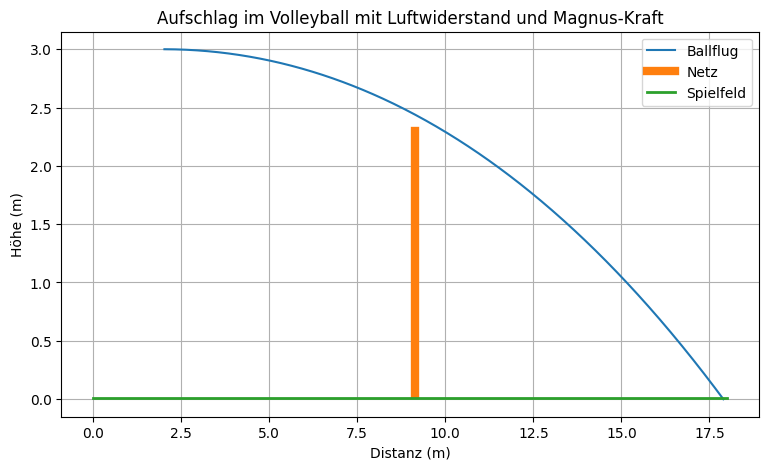

True


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Konstanten
# -----------------------------
g = 9.81    # Erdbeschleunigung in m/s^2
dichteLuft = 1.2   # Dichte der Luft in kg/m^3
lwBeiwert = 0.17   # Luftwiderstandsbeiwert für einen runden Ball
Cl = 0.3    # Magnus-Koeffizient (nicht perfekt glatt)
r = 0.105    # Radius des Balls in m
A = np.pi * r**2    # Querschnittsfläche des Balls
m = 0.270    # Masse des Balls in kg

# -----------------------------
# Spielfeld
# -----------------------------
netz_x = 9.15
netz_h = 2.30

FeldEnde = 18.0

# ----------------------------------------------------------------------
#  werte variabel zum eintellen
# ---------------------------------------------------------------------
v0 = 28
winkel = 0
spin = -10   # positiver Wert = Backspin, negativer Wert = Topspin genuzter Wer =-9
aufschlagHöhe = 3.0
dt = 0.001

# ----------------------------
# Simulation
# -----------------------------
winkel_rad = np.radians(winkel)

v = np.array([v0*np.cos(winkel_rad), v0*np.sin(winkel_rad)])    # Anfangsgeschwindigkeit in x- und y-Richtung
pos = np.array([2.0, aufschlagHöhe])  # Startposition des Balls

positionen = [] # Liste für die Positionen des Balls
ueber_netz = False
im_feld = False

while pos[1] >= 0:      # Solange der Ball den Boden nicht erreicht hat und nicht zu weit über das Tor hinausfliegt
    gesamtgeschwindigkeit = np.linalg.norm(v)   # Betrag der Geschwindigkeit; np.linalg.norm(v) = Länge des Geschwindigkeitsvektors v
    
    F_drag = -0.5 * dichteLuft * lwBeiwert * A * gesamtgeschwindigkeit * v    # Luftwiderstand
    
    F_magnus = 0.5 * dichteLuft * Cl * A * np.array([ -spin * v[1],spin * v[0]]) # Magnus-Kraft, basierend auf der Rotation des Balls
    
    F_gravity = np.array([0, -m*g])             # Schwerkraft
    a = (F_drag + F_magnus + F_gravity) / m     # Gesamtkraft pro Masse = Beschleunigung
    
    v += a * dt                     # Geschwindigkeit aktualisieren
    pos += v * dt                   # Position aktualisieren
    positionen.append(pos.copy())   # Positionen für Plot speichern
    
    # Prüfen: über Mauer?
    if abs(pos[0] - netz_x) < 0.03 and pos[1] > netz_h:
        ueber_netz = True
    
    # Prüfen: im Tor?
    if pos[0] <= FeldEnde and pos[1] <= 0:
        im_feld = True

positionen = np.array(positionen)

# -----------------------------
# Ausgabe
# -----------------------------
if ueber_netz:
    print("Ball kommt über das Netz.")
else:
    print("Ball bleibt im Netz hängen.")

if im_feld and ueber_netz:
    print("Punkt!!!")
else:
    print("Kein Punkt.")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(positionen[:,0], positionen[:,1], label="Ballflug")

# Netz
plt.plot([netz_x, netz_x], [0.03, netz_h], linewidth=6, label="Netz")

# Feld
plt.plot([18, 0.0], [0.01, 0.01], linewidth=2, label="Spielfeld")

plt.xlabel("Distanz (m)")
plt.ylabel("Höhe (m)")
plt.title("Aufschlag im Volleyball mit Luftwiderstand und Magnus-Kraft")
plt.legend()
plt.grid()
plt.show()
print(im_feld)